# F1 Fantasy 2026 - Prediction Model

## Modelling Formula 1 Outcomes for Fantasy EV Projections (2026 Season)

Adapted from the 2024 model with key updates for the 2026 regulation era:
- **22 drivers / 11 teams** (Cadillac enters as 11th team, Sauber becomes Audi)
- **New power unit regulations**: 50/50 ICE/electric split, MGU-H removed, MGU-K tripled to 350kW
- **Active aerodynamics**: DRS replaced by Boost/Overtake modes
- **Updated Fantasy scoring**: Sprint DNF now -10 (was -20), price floor $3M
- **Regulation-reset uncertainty**: Historical data weighted to account for new era

## 2026 Season Overview

### Key Rule Changes
- Smaller, lighter cars (768kg min, 200mm shorter wheelbase)
- Active aero replaces DRS (Boost button + Overtake Mode)
- 50/50 power split: ~400kW ICE + ~350kW MGU-K
- 100% sustainable fuels
- No fastest lap bonus point in real F1 (abolished 2025), but Fantasy still awards fastest lap points

### 2026 Grid
| Team | Driver 1 | Driver 2 | PU |
|------|----------|----------|-----|
| McLaren | Norris | Piastri | Mercedes |
| Mercedes | Russell | Antonelli | Mercedes |
| Red Bull | Verstappen | Hadjar | Red Bull/Ford |
| Ferrari | Leclerc | Hamilton | Ferrari |
| Williams | Albon | Sainz | Mercedes |
| Racing Bulls | Lawson | Lindblad | Red Bull/Ford |
| Aston Martin | Alonso | Stroll | Honda |
| Haas | Bearman | Ocon | Ferrari |
| Audi | Hulkenberg | Bortoleto | Audi |
| Alpine | Gasly | Colapinto | Mercedes |
| Cadillac | Perez | Bottas | Ferrari |

### Sprint Weekends (6 total)
China, Miami, Canada, Great Britain, Netherlands, Singapore

In [1]:
%pip install -q unidecode gurobipy pulp pandas seaborn scipy scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/forest.wang/Dev/f1_fantasy_model/.venv/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from itertools import product

import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from sklearn.linear_model import LinearRegression
import gurobipy as gp
from pulp import *

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# 2026 Season Constants
# ============================================================
NUM_DRIVERS = 22
NUM_TEAMS = 11
SEASON_YEAR = 2026

# Fantasy scoring constants
RACE_POINTS = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
FINISH_BONUS = 1          # +1 for classified finish
DNF_PENALTY = -20         # Race DNF
SPRINT_DNF_PENALTY = -10  # Sprint DNF (reduced from -20 in 2026)
FASTEST_LAP_PTS = 5       # Fantasy fastest lap points
Q2_BONUS = 2              # Reaching Q2
Q3_BONUS = 3              # Reaching Q3
BEAT_TEAMMATE_RACE = 3
BEAT_TEAMMATE_QUALI = 2
QUAL_STREAK_PTS = 5       # Q3 streak bonus
RACE_STREAK_PTS = 10      # Top-10 streak bonus
POS_GAIN_PTS = 2          # Per position gained (max +10)

# Budget
FANTASY_BUDGET = 100      # $100M budget cap

# 2026 driver/team mapping
TEAMS_2026 = {
    'McLaren': ['Norris', 'Piastri'],
    'Mercedes': ['Russell', 'Antonelli'],
    'Red Bull': ['Verstappen', 'Hadjar'],
    'Ferrari': ['Leclerc', 'Hamilton'],
    'Williams': ['Albon', 'Sainz'],
    'Racing Bulls': ['Lawson', 'Lindblad'],
    'Aston Martin': ['Alonso', 'Stroll'],
    'Haas': ['Bearman', 'Ocon'],
    'Audi': ['Hulkenberg', 'Bortoleto'],
    'Alpine': ['Gasly', 'Colapinto'],
    'Cadillac': ['Perez', 'Bottas'],
}

# Reverse mapping: driver -> team
DRIVER_TEAM = {}
for team, drivers in TEAMS_2026.items():
    for d in drivers:
        DRIVER_TEAM[d] = team

ALL_DRIVERS = list(DRIVER_TEAM.keys())
ALL_TEAMS = list(TEAMS_2026.keys())
print(f"Grid: {len(ALL_DRIVERS)} drivers across {len(ALL_TEAMS)} teams")

Grid: 22 drivers across 11 teams


## Part 1: Converting Odds into Implied Probabilities

The first step is to collect betting odds for each driver across 6 markets:
- `winner`: Win probability
- `top3`: Podium probability
- `top6`: Top-6 finish
- `top10`: Points finish
- `flap`: Fastest lap
- `dnf`: Did not finish

We use the shortest decimal odds available (highest implied probability) from spread betting and traditional bookmakers.

In [4]:
# Load odds data - update odds_2026.csv before each race with latest bookmaker odds
# Format: driver,team,winner,top3,top6,top10,flap,dnf
df = pd.read_csv('odds_2026.csv', index_col=0)

# Verify all 2026 drivers are present
missing = [d for d in ALL_DRIVERS if d not in df.index]
if missing:
    print(f"WARNING: Missing drivers in odds_2026.csv: {missing}")

df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Verstappen,Red Bull,2.5,1.3,1.15,1.08,4.0,15.0
Norris,McLaren,5.0,2.0,1.40,1.12,6.0,18.0
Leclerc,Ferrari,6.0,2.2,1.50,1.15,7.0,14.0
Hamilton,Ferrari,12.0,3.5,1.80,1.25,10.0,12.0
Russell,Mercedes,8.0,2.8,1.60,1.18,8.0,16.0
Piastri,McLaren,10.0,3.0,1.70,1.20,9.0,18.0
Antonelli,Mercedes,15.0,4.0,2.00,1.30,12.0,14.0
Sainz,Williams,25.0,6.0,2.50,1.40,20.0,15.0
Alonso,Aston Martin,80.0,15.0,4.00,1.80,50.0,10.0


Convert decimal odds to implied probabilities (multiplicative inverse), then correct for bookmaker overround using the power method.

In [5]:
odds_cols = ['winner', 'top3', 'top6', 'top10', 'flap', 'dnf']
for col in odds_cols:
    df[col] **= -1
df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Verstappen,Red Bull,0.400000,0.769231,0.869565,0.925926,0.250000,0.066667
Norris,McLaren,0.200000,0.500000,0.714286,0.892857,0.166667,0.055556
Leclerc,Ferrari,0.166667,0.454545,0.666667,0.869565,0.142857,0.071429
Hamilton,Ferrari,0.083333,0.285714,0.555556,0.800000,0.100000,0.083333
Russell,Mercedes,0.125000,0.357143,0.625000,0.847458,0.125000,0.062500
Piastri,McLaren,0.100000,0.333333,0.588235,0.833333,0.111111,0.055556
Antonelli,Mercedes,0.066667,0.250000,0.500000,0.769231,0.083333,0.071429
Sainz,Williams,0.040000,0.166667,0.400000,0.714286,0.050000,0.066667
Alonso,Aston Martin,0.012500,0.066667,0.250000,0.555556,0.020000,0.100000


In [6]:
def adjust_odds(odds_series, target_sum, method='power'):
    """Remove bookmaker overround using power or linear normalization."""
    if method == 'power':
        def f(x):
            return sum([i**x for i in odds_series]) - target_sum
        k = optimize.fsolve(f, 1)
        return odds_series ** k
    elif method == 'linear':
        return odds_series / sum(odds_series) * target_sum

In [7]:
# Winner sums to 1, top3 to 3, top6 to 6, top10 to 10, flap to 1
for col, target in zip(odds_cols[:-1], [1, 3, 6, 10, 1]):
    df[col] = adjust_odds(df[col], target)
df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Verstappen,Red Bull,0.352194,0.733575,0.851880,0.901524,0.222585,0.066667
Norris,McLaren,0.159932,0.441076,0.679812,0.858424,0.143433,0.055556
Leclerc,Ferrari,0.129944,0.394124,0.628088,0.828397,0.121365,0.071429
Hamilton,Ferrari,0.059008,0.227777,0.509564,0.740389,0.082454,0.083333
Russell,Mercedes,0.093640,0.296450,0.583272,0.800153,0.105013,0.062500
Piastri,McLaren,0.072626,0.273255,0.544091,0.782241,0.092428,0.055556
Antonelli,Mercedes,0.045765,0.194548,0.451558,0.702288,0.067670,0.071429
Sainz,Williams,0.025578,0.120526,0.349588,0.635568,0.038901,0.066667
Alonso,Aston Martin,0.006801,0.040846,0.203905,0.453045,0.014410,0.100000


Adjust DNF probabilities so that a driver's DNF + top10 probability cannot exceed 1. We use a log-ratio power transform anchored to the constraint that top drivers have ~96% chance of top-10 if they finish.

In [8]:
df['dnf'] **= (np.log(0.96 - df['top10']) / np.log(df['dnf'])).max()
df['winner'] = df[['winner', 'top3']].min(axis=1)
df

,team,winner,top3,top6,top10,flap,dnf
driver,,,,,,,
Verstappen,Red Bull,0.352194,0.733575,0.851880,0.901524,0.222585,0.058476
Norris,McLaren,0.159932,0.441076,0.679812,0.858424,0.143433,0.048302
Leclerc,Ferrari,0.129944,0.394124,0.628088,0.828397,0.121365,0.062862
Hamilton,Ferrari,0.059008,0.227777,0.509564,0.740389,0.082454,0.073889
Russell,Mercedes,0.093640,0.296450,0.583272,0.800153,0.105013,0.054650
Piastri,McLaren,0.072626,0.273255,0.544091,0.782241,0.092428,0.048302
Antonelli,Mercedes,0.045765,0.194548,0.451558,0.702288,0.067670,0.062862
Sainz,Williams,0.025578,0.120526,0.349588,0.635568,0.038901,0.058476
Alonso,Aston Martin,0.006801,0.040846,0.203905,0.453045,0.014410,0.089452


## Part 2: Estimating Race Finishing Position Distributions

For each driver, we solve a quadratic programming problem (Gurobi) to find the smoothest probability distribution over finishing positions P1-P22, anchored to the odds-implied probabilities for each bracket.

**2026 change**: 22 positions instead of 20 (Cadillac adds 2 drivers).

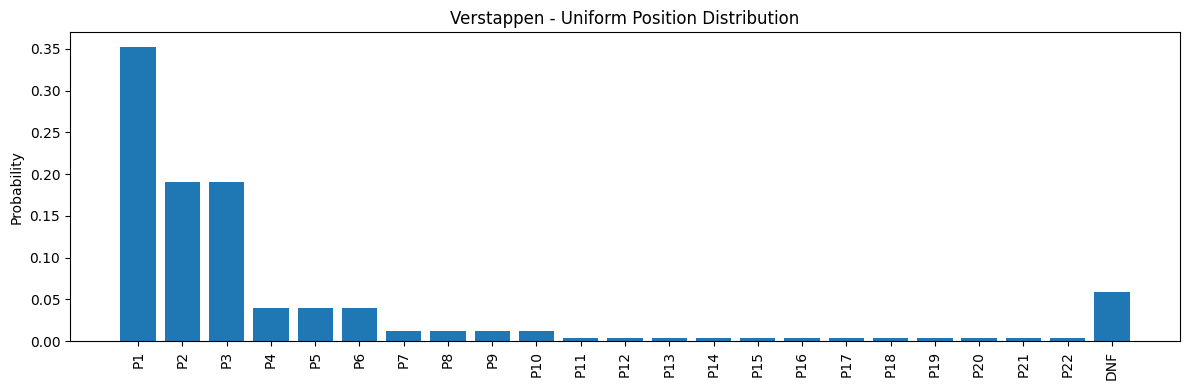

In [9]:
def get_probs(idx):
    """Get uniform distribution within each odds bracket for a driver."""
    probs = [df.loc[idx, 'winner']]
    probs += [(df.loc[idx, 'top3'] - df.loc[idx, 'winner']) / 2] * 2
    probs += [(df.loc[idx, 'top6'] - df.loc[idx, 'top3']) / 3] * 3
    probs += [(df.loc[idx, 'top10'] - df.loc[idx, 'top6']) / 4] * 4
    # 12 non-points positions for 22-driver grid (P11-P22)
    probs += [(1 - df.loc[idx, 'top10'] - df.loc[idx, 'dnf']) / 12] * 12
    probs.append(df.loc[idx, 'dnf'])
    return probs

driver = 'Verstappen'
plt.figure(figsize=(12, 4))
plt.bar(['P{}'.format(i) for i in range(1, NUM_DRIVERS + 1)] + ['DNF'], get_probs(driver))
plt.xticks(rotation=90)
plt.ylabel('Probability')
plt.title(f'{driver} - Uniform Position Distribution')
plt.tight_layout()
plt.show()

Restricted license - for non-production use only - expires 2027-11-29


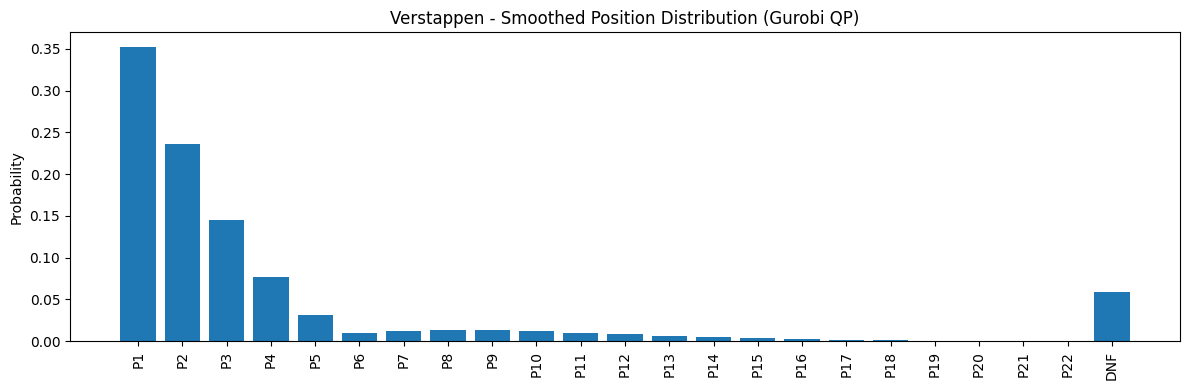

In [10]:
# Demonstrate smooth distribution for one driver
quadratic_model = gp.Model('quadratic')
quadratic_model.setParam('outputFlag', False)
driver = 'Verstappen'

# Variables: probability of finishing in each position P1-P22
x = {i: quadratic_model.addVar(vtype=gp.GRB.CONTINUOUS, lb=0, ub=1, name=f'x_{i}')
     for i in range(1, NUM_DRIVERS + 1)}

# Objective: minimize sum of squared differences between consecutive positions
obj = sum([(x[i] - x[i + 1])**2 for i in range(1, NUM_DRIVERS)])
quadratic_model.setObjective(obj, gp.GRB.MINIMIZE)

# Constraints from odds brackets
quadratic_model.addConstr(x[1] == df.loc[driver, 'winner'])
quadratic_model.addConstr(x[2] + x[3] == df.loc[driver, 'top3'] - df.loc[driver, 'winner'])
quadratic_model.addConstr(x[4] + x[5] + x[6] == df.loc[driver, 'top6'] - df.loc[driver, 'top3'])
quadratic_model.addConstr(x[7] + x[8] + x[9] + x[10] == df.loc[driver, 'top10'] - df.loc[driver, 'top6'])
quadratic_model.addConstr(sum([x[i] for i in range(11, NUM_DRIVERS + 1)]) == 1 - df.loc[driver, 'top10'] - df.loc[driver, 'dnf'])
if df.loc[driver, 'top10'] >= 0.5:
    quadratic_model.addConstr(x[NUM_DRIVERS] == 0)

quadratic_model.optimize()
vals = [v.x for v in quadratic_model.getVars()]

plt.figure(figsize=(12, 4))
plt.bar(['P{}'.format(i) for i in range(1, NUM_DRIVERS + 1)] + ['DNF'], vals + [df.loc[driver, 'dnf']])
plt.xticks(rotation=90)
plt.ylabel('Probability')
plt.title(f'{driver} - Smoothed Position Distribution (Gurobi QP)')
plt.tight_layout()
plt.show()

In [11]:
# Compute smoothed position distributions for all drivers
pos_dict = {}

for driver in df.index:
    quadratic_model = gp.Model('quadratic')
    quadratic_model.setParam('outputFlag', False)
    x = {i: quadratic_model.addVar(vtype=gp.GRB.CONTINUOUS, lb=0, ub=1, name=f'x_{i}')
         for i in range(1, NUM_DRIVERS + 1)}
    obj = sum([(x[i] - x[i + 1])**2 for i in range(1, NUM_DRIVERS)])
    quadratic_model.setObjective(obj, gp.GRB.MINIMIZE)
    quadratic_model.addConstr(x[1] == df.loc[driver, 'winner'])
    quadratic_model.addConstr(x[2] + x[3] == df.loc[driver, 'top3'] - df.loc[driver, 'winner'])
    quadratic_model.addConstr(x[4] + x[5] + x[6] == df.loc[driver, 'top6'] - df.loc[driver, 'top3'])
    quadratic_model.addConstr(x[7] + x[8] + x[9] + x[10] == df.loc[driver, 'top10'] - df.loc[driver, 'top6'])
    quadratic_model.addConstr(sum([x[i] for i in range(11, NUM_DRIVERS + 1)]) == 1 - df.loc[driver, 'top10'] - df.loc[driver, 'dnf'])
    if df.loc[driver, 'top10'] >= 0.5:
        quadratic_model.addConstr(x[NUM_DRIVERS] == 0)
    quadratic_model.optimize()
    pos_dict[driver] = {i + 1: v.x for i, v in enumerate(quadratic_model.getVars())}

print(f"Position distributions computed for {len(pos_dict)} drivers")

Position distributions computed for 22 drivers


In [12]:
pos_df = pd.DataFrame(pos_dict).T
pos_df['dnf'] = df.dnf
pos_df['team'] = df.team
pos_df['mean_pos'] = sum([i / (1 - df['dnf']) * pos_df[i] for i in range(1, NUM_DRIVERS + 1)])
pos_df.head(10).T

,Verstappen,Norris,Leclerc,Hamilton,Russell,Piastri,Antonelli,Sainz,Alonso,Hadjar
1,0.352194,0.159932,0.129944,0.059008,0.09364,0.072626,0.045765,0.025578,0.006801,0.020782
2,0.236637,0.150597,0.137676,0.078062,0.099908,0.096066,0.067586,0.040157,0.010999,0.034333
3,0.144743,0.130547,0.126505,0.090707,0.102902,0.104563,0.081197,0.054791,0.023047,0.045352
4,0.076513,0.099782,0.096431,0.096942,0.102621,0.098115,0.0866,0.069478,0.042943,0.053838
5,0.031647,0.076938,0.07508,0.096241,0.097291,0.090626,0.087253,0.078307,0.056474,0.061369
6,0.010145,0.062016,0.062452,0.088603,0.08691,0.082095,0.083156,0.081276,0.063641,0.067944
7,0.012007,0.055015,0.058546,0.074029,0.071479,0.072522,0.074309,0.078386,0.064443,0.073564
8,0.012913,0.04807,0.053596,0.06167,0.058403,0.063499,0.066119,0.074474,0.063901,0.075941
9,0.012864,0.041181,0.047602,0.051527,0.047682,0.055026,0.058588,0.069539,0.062014,0.075074
10,0.011859,0.034347,0.040564,0.043599,0.039317,0.047104,0.051714,0.063581,0.058782,0.070965


## Part 3: Race EV, Fastest Lap, and DNF Penalty

Compute expected fantasy points from race finishing position, fastest lap probability, and DNF penalty.

In [13]:
ev_df = pd.DataFrame(index=df.index)

# Race position points: P1=25, P2=18, ..., P10=1, plus +1 finish bonus
ev_df['race'] = (25 * pos_df[1] + 18 * pos_df[2] + 15 * pos_df[3]
                 + 12 * pos_df[4] + 10 * pos_df[5] + 8 * pos_df[6]
                 + 6 * pos_df[7] + 4 * pos_df[8] + 2 * pos_df[9]
                 + pos_df[10] + (1 - pos_df['dnf']) * FINISH_BONUS)

# Fastest lap (5 fantasy points)
ev_df['flap'] = df['flap'] * FASTEST_LAP_PTS

# DNF penalty (-20 points)
ev_df['dnf'] = DNF_PENALTY * df['dnf']

ev_df.sort_values('race', ascending=False).head(10)

,race,flap,dnf
driver,,,
Verstappen,17.654074,1.112924,-1.169518
Norris,12.720923,0.717167,-0.966035
Leclerc,11.670496,0.606826,-1.257247
Russell,10.325033,0.525065,-1.093003
Piastri,9.651659,0.462141,-0.966035
Hamilton,8.839085,0.412272,-1.477775
Antonelli,7.971984,0.338351,-1.257247
Sainz,6.363567,0.194505,-1.169518
Hadjar,5.519449,0.152722,-1.358825


## Part 3b: Sprint Race EV

For sprint weekends (6 in 2026), we model additional points from sprint races.
Sprint scoring: P1=8, P2=7, ..., P8=1. Sprint DNF penalty is -10 (reduced from -20 in 2026).

Since sprint results correlate with race pace, we approximate sprint EV from the position distributions.

In [14]:
# Sprint points: P1=8, P2=7, ..., P8=1
SPRINT_POINTS = {1: 8, 2: 7, 3: 6, 4: 5, 5: 4, 6: 3, 7: 2, 8: 1}
NUM_SPRINTS = 6

# Sprint EV per weekend (approximate from position distribution)
sprint_ev = sum([SPRINT_POINTS.get(i, 0) * pos_df[i] for i in range(1, NUM_DRIVERS + 1)])
sprint_ev += SPRINT_DNF_PENALTY * df['dnf']

# Scale to per-race average (6 sprints out of 24 races)
ev_df['sprint'] = sprint_ev * NUM_SPRINTS / 24

ev_df.sort_values('sprint', ascending=False).head(10)

,race,flap,dnf,sprint
driver,,,,
Verstappen,17.654074,1.112924,-1.169518,1.333558
Norris,12.720923,0.717167,-0.966035,0.946178
Leclerc,11.670496,0.606826,-1.257247,0.818552
Russell,10.325033,0.525065,-1.093003,0.720937
Piastri,9.651659,0.462141,-0.966035,0.676434
Hamilton,8.839085,0.412272,-1.477775,0.542267
Antonelli,7.971984,0.338351,-1.257247,0.486001
Sainz,6.363567,0.194505,-1.169518,0.341352
Hadjar,5.519449,0.152722,-1.358825,0.235214


## Part 4: Modelling Points from Non-Odds Sources

We use historical F1 data (2021-2025) to build regression models predicting:
1. **Qualifying EV** from mean race position (polynomial)
2. **Q2 appearance probability** (logistic regression)
3. **Q3 appearance probability** (logistic regression)
4. **Position gains EV** (linear regression)

**2026 Regulation Reset Note**: The 2022-2025 ground-effect era data is most relevant.
We use all available data but the relationships between grid/race position and fantasy points
should remain stable across regulation changes.

In [15]:
race_hist_df = pd.read_csv("f1db_csv/races.csv")
hist_result_df = pd.read_csv("f1db_csv/results.csv")

# Use 2021-2025 data (or whatever is available)
max_year = race_hist_df['year'].max()
hist_years = list(range(2021, max_year + 1))
print(f"Using historical data from {hist_years[0]} to {hist_years[-1]}")

Using historical data from 2021 to 2025


In [16]:
# Gather IDs of all races per year
race_dict = {}
for year in hist_years:
    races = race_hist_df[race_hist_df['year'] == year]['raceId'].tolist()
    race_dict[year] = races

# Collect per-driver season stats
values = {'grid': [], 'position': [], 'fantasy': [], 'top10': [], 'top15': [], 'mean_gain': []}

for year in race_dict:
    season_df = hist_result_df[hist_result_df['raceId'].isin(race_dict[year])]
    drivers = season_df['driverId'].unique()
    for driver in drivers:
        driver_season = season_df[season_df['driverId'] == driver]
        grid_pos_df = driver_season[['grid', 'position']][
            driver_season['position'].str.isnumeric() & (driver_season['grid'] != 0)
        ].copy()
        grid_pos_df['grid'] = grid_pos_df['grid'].astype(float)
        grid_pos_df['position'] = grid_pos_df['position'].astype(float)

        if len(grid_pos_df) > 15:
            values['grid'].append(grid_pos_df['grid'].mean())
            values['position'].append(grid_pos_df['position'].mean())
            values['fantasy'].append(
                sum([sum(grid_pos_df['grid'] == i) * (11 - i) for i in range(1, 11)]) / len(grid_pos_df)
            )
            values['top10'].append(sum(grid_pos_df['grid'] <= 10) / len(grid_pos_df))
            values['top15'].append(sum(grid_pos_df['grid'] <= 15) / len(grid_pos_df))

            total = 0
            for idx in grid_pos_df.index:
                g = grid_pos_df.loc[idx, 'grid']
                p = grid_pos_df.loc[idx, 'position']
                if g - p > 0:
                    total += min(10, (g - p) * POS_GAIN_PTS)
                elif g - p < 0:
                    if g <= 10:
                        total += max(-10, (g - p) * POS_GAIN_PTS)
                    else:
                        total += max(-5, g - p)
            values['mean_gain'].append(total / len(grid_pos_df))

hist_stats_df = pd.DataFrame(values)
print(f"Collected {len(hist_stats_df)} driver-seasons for regression")
hist_stats_df.head()

Collected 95 driver-seasons for regression


,grid,position,fantasy,top10,top15,mean_gain
0,3.047619,2.761905,7.952381,0.952381,1.000000,0.857143
1,3.052632,1.842105,8.421053,0.947368,0.947368,1.157895
2,5.777778,5.000000,6.055556,0.833333,0.888889,0.666667
3,6.904762,6.619048,4.714286,0.857143,0.952381,0.380952
4,5.500000,5.250000,5.500000,0.937500,1.000000,1.500000


### Qualifying EV from Mean Race Position

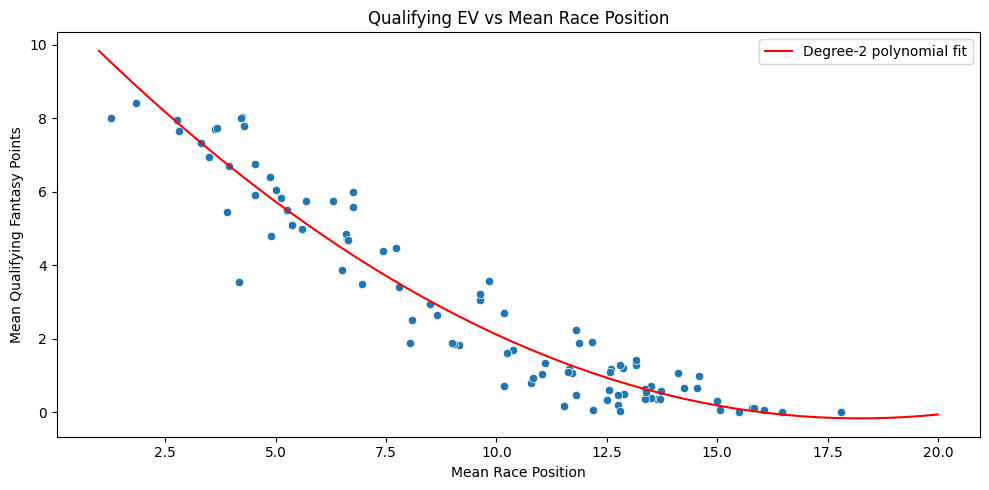

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='position', y='fantasy', data=hist_stats_df)
weights = np.polyfit(hist_stats_df['position'], hist_stats_df['fantasy'], 2)
model_qual = np.poly1d(weights)
x_line = np.linspace(1, 20)
plt.plot(x_line, model_qual(x_line), 'r-', label='Degree-2 polynomial fit')
plt.xlabel('Mean Race Position')
plt.ylabel('Mean Qualifying Fantasy Points')
plt.title('Qualifying EV vs Mean Race Position')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
def qual_pts(pos):
    weights = np.polyfit(hist_stats_df['position'], hist_stats_df['fantasy'], 2)
    model = np.poly1d(weights)
    return max(model(pos), 0)

### Q2 Appearance Probability (Logistic Regression)

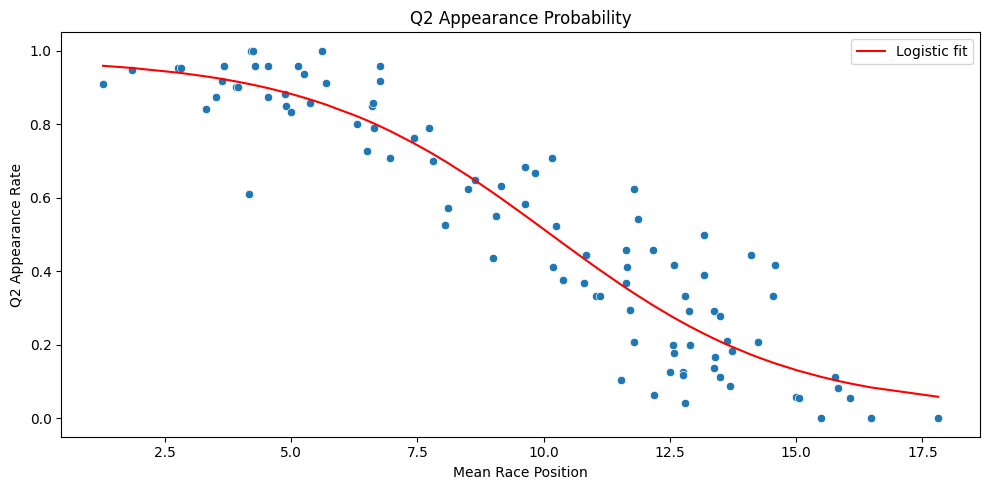

In [19]:
hist_stats_df = hist_stats_df.sort_values(by='position')

plt.figure(figsize=(10, 5))
sns.scatterplot(x=hist_stats_df['position'], y=hist_stats_df['top10'])

x_data = hist_stats_df['position'].to_numpy()
y_data = hist_stats_df['top10'].to_numpy()

def logistic_f(x, a, b, c, d):
    return a / (1. + np.exp(-c * (x - d))) + b

popt, pcov = optimize.curve_fit(logistic_f, x_data, y_data, method="trf")
y_fit = logistic_f(x_data, *popt)
plt.plot(x_data, y_fit, 'r-', label='Logistic fit')
plt.xlabel('Mean Race Position')
plt.ylabel('Q2 Appearance Rate')
plt.title('Q2 Appearance Probability')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
def q2_finish_pts(pos):
    x = hist_stats_df['position'].to_numpy()
    y = hist_stats_df['top10'].to_numpy()
    def f(x, a, b, c, d):
        return a / (1. + np.exp(-c * (x - d))) + b
    popt, pcov = optimize.curve_fit(f, x, y, method="trf")
    return f(pos, *popt) * Q2_BONUS

### Q3 Appearance Probability

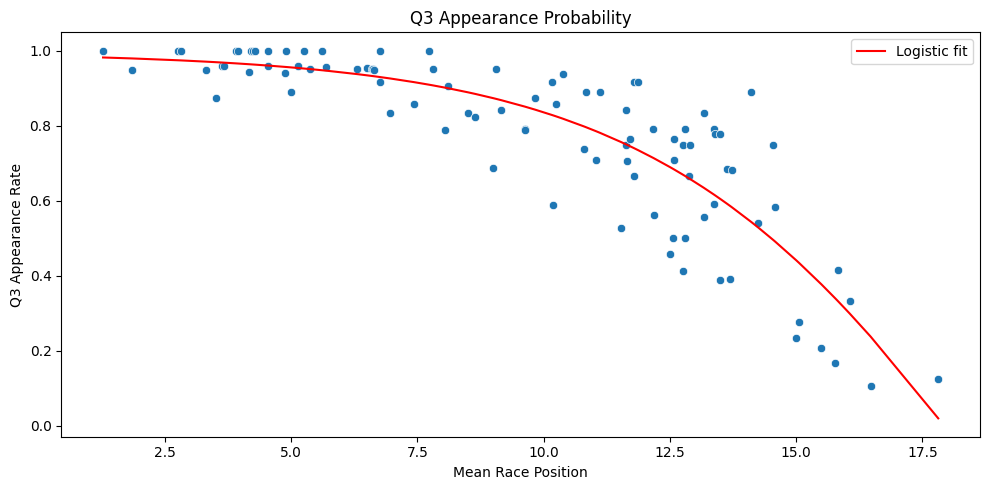

In [21]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=hist_stats_df['position'], y=hist_stats_df['top15'])

x_data = hist_stats_df['position'].to_numpy()
y_data = hist_stats_df['top15'].to_numpy()

popt, pcov = optimize.curve_fit(logistic_f, x_data, y_data, method="trf")
y_fit = logistic_f(x_data, *popt)
plt.plot(x_data, y_fit, 'r-', label='Logistic fit')
plt.xlabel('Mean Race Position')
plt.ylabel('Q3 Appearance Rate')
plt.title('Q3 Appearance Probability')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
def q3_finish_pts(pos):
    x = hist_stats_df['position'].to_numpy()
    y = hist_stats_df['top15'].to_numpy()
    def f(x, a, b, c, d):
        return a / (1. + np.exp(-c * (x - d))) + b
    popt, pcov = optimize.curve_fit(f, x, y, method="trf")
    return max(f(pos, *popt) * Q3_BONUS, 0)

### Position Gains EV

<Figure size 1000x500 with 0 Axes>

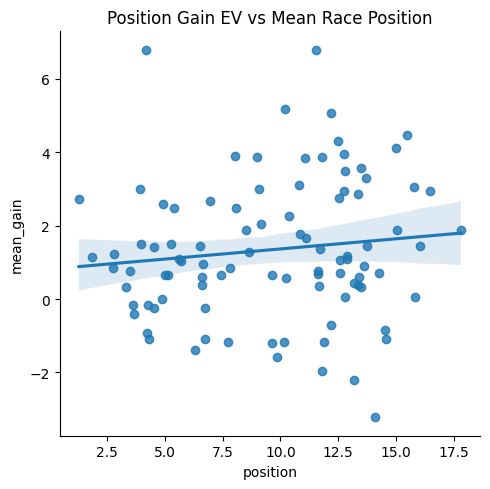

In [23]:
plt.figure(figsize=(10, 5))
sns.lmplot(x='position', y='mean_gain', data=hist_stats_df)
plt.title('Position Gain EV vs Mean Race Position')
plt.tight_layout()
plt.show()

In [24]:
def gain_pts(pos):
    x = hist_stats_df['position'].values.reshape(-1, 1)
    y = hist_stats_df['mean_gain'].values.reshape(-1, 1)
    reg = LinearRegression().fit(x, y)
    return reg.predict(np.array(pos).reshape(-1, 1))[0][0]

### Apply Regression Models to 2026 Drivers

In [25]:
ev_df['qual'] = [qual_pts(i) for i in pos_df['mean_pos']]
ev_df['gain'] = [gain_pts(i) for i in pos_df['mean_pos']]
ev_df['q'] = [q2_finish_pts(i) + q3_finish_pts(i) for i in pos_df['mean_pos']]

ev_df.sort_values('qual', ascending=False).head(10)

,race,flap,dnf,sprint,qual,gain,q
driver,,,,,,,
Verstappen,17.654074,1.112924,-1.169518,1.333558,7.746506,0.972926,4.796251
Norris,12.720923,0.717167,-0.966035,0.946178,5.801760,1.084102,4.639233
Leclerc,11.670496,0.606826,-1.257247,0.818552,5.455325,1.105725,4.594790
Russell,10.325033,0.525065,-1.093003,0.720937,4.787050,1.149408,4.487112
Piastri,9.651659,0.462141,-0.966035,0.676434,4.477708,1.170626,4.425241
Hamilton,8.839085,0.412272,-1.477775,0.542267,4.175920,1.192018,4.355985
Antonelli,7.971984,0.338351,-1.257247,0.486001,3.671870,1.229478,4.217207
Sainz,6.363567,0.194505,-1.169518,0.341352,2.925425,1.289810,3.945701
Hadjar,5.519449,0.152722,-1.358825,0.235214,2.527038,1.325021,3.761092


## Part 5: Teammate Comparisons

We scrape current-season results to estimate the probability of each driver beating their teammate.
Probabilities are Bayesian-shrunk toward 0.5 to account for small sample sizes.

Since the 2026 season hasn't started yet (or has just begun), we use pre-season estimates
based on relative expected positions from odds, or early-season data as available.

In [26]:
# 2026 race URLs - update this list as races complete
# Format: "raceId/circuit-name"
hrefs = [
    # "XXXX/australia",  # Round 1 - Melbourne
    # Add race URLs as the season progresses
]

# https://www.formula1.com/en/results.html/2026/races/XXXX/australia/qualifying.html
qualifying_dfs, race_dfs, grid_dfs = [], [], []
season_length = 0  # Update after each race

for href in hrefs[:season_length]:
    qualifying_url = f'https://www.formula1.com/en/results.html/2026/races/{href}/qualifying.html'
    qual_result = pd.read_html(qualifying_url)[0]
    qual_result['Driver'] = [unidecode.unidecode(name.split('  ')[1]) for name in qual_result['Driver']]
    qualifying_dfs.append(qual_result.set_index('Driver')[['Pos', 'Car', 'Q2', 'Q3']])

    race_url = f'https://www.formula1.com/en/results.html/2026/races/{href}.html'
    race_result = pd.read_html(race_url)[0]
    race_result['Driver'] = [unidecode.unidecode(name.split('  ')[1]) for name in race_result['Driver']]
    race_dfs.append(race_result.set_index('Driver')[['Pos', 'Car', 'Time/Retired']])

    grid_url = f'https://www.formula1.com/en/results.html/2026/races/{href}/starting-grid.html'
    grid_result = pd.read_html(grid_url)[0]
    grid_result['Driver'] = [unidecode.unidecode(name.split('  ')[1]) for name in grid_result['Driver']]
    grid_dfs.append(grid_result.set_index('Driver')[['Pos', 'Car']])

print(f"Loaded {season_length} race(s) of 2026 season data")

Loaded 0 race(s) of 2026 season data


In [27]:
if season_length > 0 and len(race_dfs) > 0:
    # Use actual season data
    drivers_list = race_dfs[0].index
    event_df = pd.DataFrame(index=drivers_list)
    event_df['team'] = race_dfs[0].Car
    event_df['beat_teammate_race'] = np.empty((len(drivers_list), 0)).tolist()
    event_df['beat_teammate_qualifying'] = np.empty((len(drivers_list), 0)).tolist()

    for i, (r_df, q_df, g_df) in enumerate(zip(race_dfs, qualifying_dfs, grid_dfs)):
        for team_name in r_df['Car'].unique():
            team_r = r_df.loc[r_df['Car'] == team_name]
            try:
                event_df.loc[team_r.index[0], 'beat_teammate_race'].append(1)
                event_df.loc[team_r.index[1], 'beat_teammate_race'].append(0)
            except (IndexError, KeyError):
                continue
            team_q = q_df.loc[q_df['Car'] == team_name]
            try:
                event_df.loc[team_q.index[0], 'beat_teammate_qualifying'].append(1)
                event_df.loc[team_q.index[1], 'beat_teammate_qualifying'].append(0)
            except (IndexError, KeyError):
                continue

    # Bayesian shrinkage toward 0.5
    event_df['P(beat_teammate_race)'] = [np.mean(l) if l else 0.5 for l in event_df['beat_teammate_race']]
    event_df['P(beat_teammate_race)'] = (5 * event_df['P(beat_teammate_race)'] + 0.5) / 6
    event_df['P(beat_teammate_qualifying)'] = [np.mean(l) if l else 0.5 for l in event_df['beat_teammate_qualifying']]
    event_df['P(beat_teammate_qualifying)'] = (5 * event_df['P(beat_teammate_qualifying)'] + 0.5) / 6
    event_df = pd.DataFrame(event_df[['team', 'P(beat_teammate_race)', 'P(beat_teammate_qualifying)']])
else:
    # Pre-season estimates based on driver strength priors from odds
    event_df = pd.DataFrame(index=df.index)
    event_df['team'] = df['team']

    for team_name, team_drivers in TEAMS_2026.items():
        if all(d in pos_df.index for d in team_drivers):
            d1, d2 = team_drivers
            mp1 = pos_df.loc[d1, 'mean_pos']
            mp2 = pos_df.loc[d2, 'mean_pos']
            # Convert to win probability using logistic function
            diff = mp2 - mp1  # positive if d1 is stronger
            p1 = 1 / (1 + np.exp(-0.3 * diff))
            p1 = (5 * p1 + 0.5) / 6  # shrink toward 0.5
            event_df.loc[d1, 'P(beat_teammate_race)'] = p1
            event_df.loc[d2, 'P(beat_teammate_race)'] = 1 - p1
            event_df.loc[d1, 'P(beat_teammate_qualifying)'] = p1
            event_df.loc[d2, 'P(beat_teammate_qualifying)'] = 1 - p1

print("Teammate beat probabilities:")
event_df[['team', 'P(beat_teammate_race)', 'P(beat_teammate_qualifying)']].sort_values('P(beat_teammate_race)', ascending=False)

Teammate beat probabilities:


,team,P(beat_teammate_race),P(beat_teammate_qualifying)
driver,,,
Verstappen,Red Bull,0.809615,0.809615
Sainz,Williams,0.733468,0.733468
Lawson,Racing Bulls,0.709222,0.709222
Gasly,Alpine,0.688976,0.688976
Alonso,Aston Martin,0.681873,0.681873
Norris,McLaren,0.596252,0.596252
Leclerc,Ferrari,0.596004,0.596004
Russell,Mercedes,0.589303,0.589303
Hulkenberg,Audi,0.560749,0.560749


In [28]:
# Adjust teammate probabilities for DNF scenarios
for team_name in event_df['team'].unique():
    team_drivers = event_df[event_df['team'] == team_name].index.tolist()
    if len(team_drivers) != 2:
        continue
    d1, d2 = team_drivers[0], team_drivers[1]
    if d1 not in df.index or d2 not in df.index:
        continue

    p_no_dnf = (1 - df.loc[d1, 'dnf']) * (1 - df.loc[d2, 'dnf'])
    adjusted = adjust_odds(
        np.array(event_df.loc[[d1, d2], 'P(beat_teammate_race)']),
        p_no_dnf, method='linear'
    )
    event_df.loc[[d1, d2], 'P(beat_teammate_race)'] = adjusted

    # Add unilateral DNF scenarios
    event_df.loc[d1, 'P(beat_teammate_race)'] += (1 - df.loc[d1, 'dnf']) * df.loc[d2, 'dnf']
    event_df.loc[d2, 'P(beat_teammate_race)'] += (1 - df.loc[d2, 'dnf']) * df.loc[d1, 'dnf']

event_df

,team,P(beat_teammate_race),P(beat_teammate_qualifying)
driver,,,
Verstappen,Red Bull,0.774451,0.809615
Norris,McLaren,0.586012,0.596252
Leclerc,Ferrari,0.586512,0.596004
Hamilton,Ferrari,0.408843,0.403996
Russell,Mercedes,0.581504,0.589303
Piastri,McLaren,0.411655,0.403748
Antonelli,Mercedes,0.415060,0.410697
Sainz,Williams,0.706353,0.733468
Alonso,Aston Martin,0.649816,0.681873


In [29]:
for driver in df.index:
    if driver in event_df.index:
        ev_df.loc[driver, 'beat_teammate'] = (
            event_df.loc[driver, 'P(beat_teammate_race)'] * BEAT_TEAMMATE_RACE
            + event_df.loc[driver, 'P(beat_teammate_qualifying)'] * BEAT_TEAMMATE_QUALI
        )
    else:
        print(f"Warning: {driver} not in event_df")
        ev_df.loc[driver, 'beat_teammate'] = 0

## Part 6: Streak Modelling

Drivers earn bonus points for consecutive qualifying/race streaks:
- **Qualifying streak**: Q3 in consecutive races -> +5 points per race
- **Race streak**: Top-10 in consecutive races -> +10 points per race

Update these lists based on current streak status:

In [30]:
# UPDATE: Drivers currently on streaks (empty at season start)
q_streak_drivers = []    # Drivers on Q3 qualifying streaks
race_streak_drivers = [] # Drivers on top-10 race streaks

In [31]:
for driver in pos_df.index:
    if driver in q_streak_drivers:
        streak_prob = q3_finish_pts(pos_df.loc[driver, 'mean_pos']) / Q3_BONUS
        ev_df.loc[driver, 'q_streak'] = streak_prob * QUAL_STREAK_PTS
    else:
        ev_df.loc[driver, 'q_streak'] = 0

for driver in pos_df.index:
    if driver in race_streak_drivers:
        streak_prob = sum([pos_df.loc[driver, i] for i in range(1, 11)])
        ev_df.loc[driver, 'race_streak'] = streak_prob * RACE_STREAK_PTS
    else:
        ev_df.loc[driver, 'race_streak'] = 0

ev_df

,race,flap,dnf,sprint,qual,gain,q,beat_teammate,q_streak,race_streak
driver,,,,,,,,,,
Verstappen,17.654074,1.112924,-1.169518,1.333558,7.746506,0.972926,4.796251,3.942582,0.0,0.0
Norris,12.720923,0.717167,-0.966035,0.946178,5.801760,1.084102,4.639233,2.950539,0.0,0.0
Leclerc,11.670496,0.606826,-1.257247,0.818552,5.455325,1.105725,4.594790,2.951545,0.0,0.0
Hamilton,8.839085,0.412272,-1.477775,0.542267,4.175920,1.192018,4.355985,2.034520,0.0,0.0
Russell,10.325033,0.525065,-1.093003,0.720937,4.787050,1.149408,4.487112,2.923119,0.0,0.0
Piastri,9.651659,0.462141,-0.966035,0.676434,4.477708,1.170626,4.425241,2.042462,0.0,0.0
Antonelli,7.971984,0.338351,-1.257247,0.486001,3.671870,1.229478,4.217207,2.066574,0.0,0.0
Sainz,6.363567,0.194505,-1.169518,0.341352,2.925425,1.289810,3.945701,3.585996,0.0,0.0
Alonso,4.038510,0.072052,-1.789050,0.049869,1.464997,1.434362,3.092412,3.313193,0.0,0.0


## Part 7: Final EV Compilation

In [32]:
driver_df = pd.DataFrame(ev_df.T.sum(), columns=['EV'])

print("=== Driver EV Rankings ===")
driver_df.sort_values(by='EV', ascending=False)

=== Driver EV Rankings ===


,EV
driver,
Verstappen,36.389303
Norris,27.893866
Leclerc,25.946012
Russell,23.824721
Piastri,21.940236
Hamilton,20.074293
Antonelli,18.724218
Sainz,17.476837
Hadjar,13.207210


In [33]:
team_df = pd.DataFrame(index=pos_df['team'].unique().tolist())

for team in pos_df['team'].unique():
    t_df = ev_df[pos_df['team'] == team]
    team_df.loc[team, 'EV'] = (
        t_df['race'].sum() + t_df['qual'].sum() + t_df['q'].sum()
        + t_df['gain'].sum() + t_df['sprint'].sum()
    )

print("=== Constructor EV Rankings ===")
team_df.sort_values(by='EV', ascending=False)

=== Constructor EV Rankings ===


,EV
Red Bull,45.871129
McLaren,45.593864
Ferrari,42.750164
Mercedes,39.046080
Williams,22.543077
Aston Martin,15.881806
Racing Bulls,14.115622
Alpine,13.450328
Haas,12.654433
Audi,9.255180


In [34]:
# UPDATE: Teams currently on streaks
q_streak_teams = []
race_streak_teams = []

for team in q_streak_teams:
    drivers_t = pos_df[pos_df['team'] == team].index.tolist()
    streak_prob = (q3_finish_pts(pos_df.loc[drivers_t[0], 'mean_pos']) / Q3_BONUS
                   * q3_finish_pts(pos_df.loc[drivers_t[1], 'mean_pos']) / Q3_BONUS)
    team_df.loc[team, 'EV'] += streak_prob * QUAL_STREAK_PTS

for team in race_streak_teams:
    drivers_t = pos_df[pos_df['team'] == team].index.tolist()
    streak_prob = (sum([pos_df.loc[drivers_t[0], i] for i in range(1, 11)])
                   * sum([pos_df.loc[drivers_t[1], i] for i in range(1, 11)]))
    team_df.loc[team, 'EV'] += streak_prob * RACE_STREAK_PTS

team_df.sort_values(by='EV', ascending=False)

,EV
Red Bull,45.871129
McLaren,45.593864
Ferrari,42.750164
Mercedes,39.046080
Williams,22.543077
Aston Martin,15.881806
Racing Bulls,14.115622
Alpine,13.450328
Haas,12.654433
Audi,9.255180


## Part 8: Team Optimization (PuLP Integer LP)

Using the EV projections, solve for the optimal Fantasy team:
- **5 drivers + 2 constructors**
- **Budget**: $100M
- **1 turbo driver** (scores double)
- Subject to transfer constraints from current team

In [35]:
# Fetch live 2026 Fantasy prices from official F1 Fantasy site
# Falls back to _prices.csv if scraping fails (e.g. no Playwright installed)

async def fetch_f1_fantasy_prices():
    """Scrape current driver/constructor prices from fantasy.formula1.com using Playwright."""
    try:
        from playwright.async_api import async_playwright
    except ImportError:
        print("Playwright not installed - using CSV fallback")
        return None, None

    captured = {'data': None}

    async def handle_response(response):
        if 'feeds/drivers/' in response.url and response.status == 200:
            try:
                captured['data'] = await response.json()
            except:
                pass

    try:
        async with async_playwright() as pw:
            browser = await pw.chromium.launch(headless=True)
            page = await browser.new_page()
            page.on('response', handle_response)
            await page.goto('https://fantasy.formula1.com/en/statistics/details?tab=driver&filter=fPoints', timeout=30000)
            await page.wait_for_timeout(5000)
            await browser.close()
    except Exception as e:
        print(f"Playwright scraping failed: {e}")
        return None, None

    if not captured['data']:
        print("No data captured from F1 Fantasy site")
        return None, None

    players = captured['data'].get('Data', {}).get('Value', [])

    # Name mapping from F1 Fantasy LastName to our model names
    name_map = {
        'Verstappen': 'Verstappen', 'Norris': 'Norris', 'Leclerc': 'Leclerc',
        'Russell': 'Russell', 'Piastri': 'Piastri', 'Hamilton': 'Hamilton',
        'Antonelli': 'Antonelli', 'Sainz': 'Sainz', 'Hadjar': 'Hadjar',
        'Alonso': 'Alonso', 'Lawson': 'Lawson', 'Gasly': 'Gasly',
        'Ocon': 'Ocon', 'Albon': 'Albon', 'Bearman': 'Bearman',
        'Hulkenberg': 'Hulkenberg', 'Stroll': 'Stroll', 'Colapinto': 'Colapinto',
        'Lindblad': 'Lindblad', 'Perez': 'Perez', 'Bottas': 'Bottas',
        'Bortoleto': 'Bortoleto', 'Hülkenberg': 'Hulkenberg',
    }
    # Team name mapping
    team_map = {
        'Red Bull Racing': 'Red Bull',
        'Haas F1 Team': 'Haas',
    }

    driver_prices = {}
    constructor_prices = {}
    for p in players:
        price = float(p.get('Value', 0))
        if p.get('PositionName') == 'DRIVER':
            last = p.get('LastName', '')
            name = name_map.get(last, last)
            driver_prices[name] = price
        elif p.get('PositionName') == 'CONSTRUCTOR':
            cname = p.get('FUllName', '')
            cname = team_map.get(cname, cname)
            constructor_prices[cname] = price

    return driver_prices, constructor_prices

# Try live prices first
print("Fetching live prices from fantasy.formula1.com...")
live_driver_prices, live_constructor_prices = await fetch_f1_fantasy_prices()

if live_driver_prices and live_constructor_prices:
    print(f"SUCCESS: Got {len(live_driver_prices)} driver + {len(live_constructor_prices)} constructor prices")
    driver_prices = live_driver_prices
    team_prices = live_constructor_prices

    # Update _prices.csv with latest prices for offline fallback
    rows = []
    for d, price in sorted(driver_prices.items(), key=lambda x: -x[1]):
        team = df.loc[d, 'team'] if d in df.index else ''
        rows.append(f"{d},{team},{price},0")
    for t, price in sorted(team_prices.items(), key=lambda x: -x[1]):
        rows.append(f"{t},,{price},1")
    with open('_prices.csv', 'w') as f:
        f.write('driver,team,price,is_constructor\n' + '\n'.join(rows) + '\n')
    print("Updated _prices.csv with live prices")
else:
    # Fallback to CSV
    print("Using _prices.csv fallback...")
    prices_pd = pd.read_csv('_prices.csv')
    driver_prices_df = prices_pd[prices_pd['is_constructor'] == 0]
    constructor_prices_df = prices_pd[prices_pd['is_constructor'] == 1]
    driver_prices = dict(zip(driver_prices_df['driver'], driver_prices_df['price']))
    team_prices = dict(zip(constructor_prices_df['driver'], constructor_prices_df['price']))

# Assign prices to dataframes
for d in driver_prices:
    if d in driver_df.index:
        driver_df.loc[d, 'price'] = driver_prices[d]
for t in team_prices:
    if t in team_df.index:
        team_df.loc[t, 'price'] = team_prices[t]

# Check for missing prices
for d in ALL_DRIVERS:
    if d not in driver_prices:
        driver_df.loc[d, 'price'] = 5.0
        print(f"  WARNING: Missing price for {d}, using $5.0M placeholder")
for t in ALL_TEAMS:
    if t not in team_prices:
        team_df.loc[t, 'price'] = 5.0
        print(f"  WARNING: Missing price for {t}, using $5.0M placeholder")

print("\nDriver Prices:")
print(driver_df[['price', 'EV']].sort_values('EV', ascending=False))
print("\nConstructor Prices:")
print(team_df[['price', 'EV']].sort_values('EV', ascending=False))

Fetching live prices from fantasy.formula1.com...


SUCCESS: Got 22 driver + 11 constructor prices
Updated _prices.csv with live prices

Driver Prices:
            price         EV
driver                      
Verstappen   27.7  36.389303
Norris       27.2  27.893866
Leclerc      22.8  25.946012
Russell      27.4  23.824721
Piastri      25.5  21.940236
Hamilton     22.5  20.074293
Antonelli    23.2  18.724218
Sainz        11.8  17.476837
Hadjar       15.1  13.207210
Alonso       10.0  11.676346
Lawson        6.5  11.480081
Gasly        12.0  10.710154
Ocon          7.3   7.987325
Albon        11.6   7.866246
Bearman       7.4   6.629755
Hulkenberg    6.8   6.188813
Stroll        8.0   5.497650
Colapinto     6.2   4.534559
Lindblad      6.2   4.442846
Perez         6.0   4.387158
Bortoleto     6.4   4.302542
Bottas        5.9   3.871717

Constructor Prices:
              price         EV
Red Bull       28.2  45.871129
McLaren        28.9  45.593864
Ferrari        23.3  42.750164
Mercedes       29.3  39.046080
Williams       12.0  22.5430

In [36]:
# Value analysis: EV per $M
driver_df['EV/$M'] = driver_df['EV'] / driver_df['price']
team_df['EV/$M'] = team_df['EV'] / team_df['price']

print("=== Best Value Drivers (EV/$M) ===")
display(driver_df.sort_values('EV/$M', ascending=False))
print("\n=== Best Value Teams (EV/$M) ===")
display(team_df.sort_values('EV/$M', ascending=False))

=== Best Value Drivers (EV/$M) ===


,EV,price,EV/$M
driver,,,
Lawson,11.480081,6.5,1.766166
Sainz,17.476837,11.8,1.481088
Verstappen,36.389303,27.7,1.313693
Alonso,11.676346,10.0,1.167635
Leclerc,25.946012,22.8,1.137983
Ocon,7.987325,7.3,1.094154
Norris,27.893866,27.2,1.025510
Hulkenberg,6.188813,6.8,0.910120
Bearman,6.629755,7.4,0.895913



=== Best Value Teams (EV/$M) ===


,EV,price,EV/$M
Racing Bulls,14.115622,6.3,2.240575
Williams,22.543077,12.0,1.878590
Ferrari,42.750164,23.3,1.834771
Haas,12.654433,7.4,1.710058
Red Bull,45.871129,28.2,1.626636
McLaren,45.593864,28.9,1.577642
Aston Martin,15.881806,10.3,1.541923
Audi,9.255180,6.6,1.402300
Mercedes,39.046080,29.3,1.332631
Cadillac,7.792029,6.0,1.298672


In [37]:
pd.concat([
    team_df.sort_values(by='EV', ascending=False),
    driver_df.sort_values(by='EV', ascending=False)
])

,EV,price,EV/$M
Red Bull,45.871129,28.2,1.626636
McLaren,45.593864,28.9,1.577642
Ferrari,42.750164,23.3,1.834771
Mercedes,39.046080,29.3,1.332631
Williams,22.543077,12.0,1.878590
Aston Martin,15.881806,10.3,1.541923
Racing Bulls,14.115622,6.3,2.240575
Alpine,13.450328,12.5,1.076026
Haas,12.654433,7.4,1.710058
Audi,9.255180,6.6,1.402300


In [38]:
def solve_team(budget, owned_drivers, owned_team, force_include, force_exclude, transfers=3):
    """
    Solve for optimal F1 Fantasy team using integer linear programming.
    
    Args:
        budget: Total budget in $M
        owned_drivers: List of currently owned driver names
        owned_team: List of currently owned team names
        force_include: Dict with 'driver' and 'team' lists to force into solution
        force_exclude: Dict with 'driver' and 'team' lists to exclude
        transfers: Number of available transfers
    
    Returns:
        Dict with optimal drivers, teams, turbo driver, and total EV
    """
    owned_d = {d: int(d in owned_drivers) for d in driver_df.index}
    owned_t = {c: int(c in owned_team) for c in team_df.index}

    prob = LpProblem("F1_Fantasy_2026", LpMaximize)
    drivers = LpVariable.dicts('drivers', driver_df.index, cat='Binary')
    teams = LpVariable.dicts('teams', team_df.index, cat='Binary')
    turbo = LpVariable.dicts('turbo', driver_df.index, cat='Binary')

    # Objective: maximize total EV (turbo driver scores double)
    prob += (lpSum([drivers[d] * driver_df.loc[d, 'EV'] for d in drivers])
             + lpSum([teams[t] * team_df.loc[t, 'EV'] for t in teams])
             + lpSum([turbo[d] * driver_df.loc[d, 'EV'] for d in drivers]))

    # Constraints
    prob += lpSum(drivers) == 5           # Exactly 5 drivers
    prob += lpSum(teams) == 2             # Exactly 2 constructors
    prob += lpSum(turbo) == 1             # Exactly 1 turbo driver

    # Budget constraint
    prob += (lpSum([drivers[d] * driver_df.loc[d, 'price'] for d in drivers])
             + lpSum([teams[t] * team_df.loc[t, 'price'] for t in teams]) <= budget)

    # Turbo driver must be selected
    for d in drivers:
        prob += turbo[d] <= drivers[d]

    # Transfer constraint
    prob += (lpSum([owned_d[d] * drivers[d] for d in drivers])
             + lpSum([owned_t[t] * teams[t] for t in teams]) >= 7 - transfers)

    # Force include/exclude
    for d in force_include.get('driver', []):
        if d in drivers:
            prob += drivers[d] == 1
    for t in force_include.get('team', []):
        if t in teams:
            prob += teams[t] == 1
    for d in force_exclude.get('driver', []):
        if d in drivers:
            prob += drivers[d] == 0
    for t in force_exclude.get('team', []):
        if t in teams:
            prob += teams[t] == 0

    prob.solve(PULP_CBC_CMD(msg=0))

    return {
        'drivers': sorted([d for d in drivers if drivers[d].varValue == 1],
                          key=lambda x: -driver_prices.get(x, 0)),
        'team': sorted([t for t in teams if teams[t].varValue == 1],
                       key=lambda x: -team_prices.get(x, 0)),
        'turbo driver': [d for d in drivers if turbo[d].varValue == 1][0],
        'EV': value(prob.objective)
    }

### Optimal Team Selection

In [39]:
# ============================================================
# UPDATE: Your current team and constraints
# ============================================================

# Fresh start - optimal team with no constraints
print("=== Optimal Team (Fresh Start) ===")
print(solve_team(
    budget=FANTASY_BUDGET,
    owned_drivers=[],
    owned_team=[],
    force_include={'driver': [], 'team': []},
    force_exclude={'driver': [], 'team': []},
    transfers=12
))

=== Optimal Team (Fresh Start) ===
{'drivers': ['Verstappen', 'Sainz', 'Alonso', 'Ocon', 'Lawson'], 'team': ['Ferrari', 'Williams'], 'turbo driver': 'Verstappen', 'EV': np.float64(186.69243628218268)}


In [40]:
# Optimal teams across budget range
optimal_teams = {}
min_budget, max_budget = 95, FANTASY_BUDGET
last_team = {}
b = min_budget

while b <= max_budget:
    b = round(b, 1)
    team = solve_team(
        budget=b,
        owned_drivers=[],
        owned_team=[],
        force_include={'driver': [], 'team': []},
        force_exclude={'driver': [], 'team': []},
        transfers=12
    )
    if team != last_team:
        optimal_teams[b] = team
    last_team = team
    b += 0.1

out_df = pd.DataFrame(optimal_teams).T
for i in range(5):
    out_df[f'driver {i+1}'] = [d[i] for d in out_df['drivers']]
out_df.index = [f'{out_df.index[i-1]}-{round(out_df.index[i] - 0.1, 1)}'
                for i in range(1, len(out_df))] + [f'{out_df.index[-1]}-{max_budget}']
out_df.index.name = 'budget range'
out_df.drop('drivers', axis=1)[['driver 1', 'driver 2', 'driver 3', 'driver 4', 'driver 5',
                                 'turbo driver', 'team', 'EV']]

,driver 1,driver 2,driver 3,driver 4,driver 5,turbo driver,team,EV
budget range,,,,,,,,
95.0-95.3,Verstappen,Sainz,Ocon,Lawson,Colapinto,Verstappen,"[Ferrari, Williams]",179.55065
95.4-95.9,Verstappen,Sainz,Ocon,Hulkenberg,Lawson,Verstappen,"[Ferrari, Williams]",181.204904
96.0-97.1,Verstappen,Sainz,Bearman,Ocon,Lawson,Verstappen,"[Ferrari, Williams]",181.645845
97.2-97.2,Verstappen,Sainz,Alonso,Lawson,Bottas,Verstappen,"[Ferrari, Williams]",182.576828
97.3-97.4,Verstappen,Sainz,Alonso,Lawson,Perez,Verstappen,"[Ferrari, Williams]",183.092269
97.5-98.0,Verstappen,Sainz,Alonso,Lawson,Colapinto,Verstappen,"[Ferrari, Williams]",183.23967
98.1-98.5,Verstappen,Sainz,Alonso,Hulkenberg,Lawson,Verstappen,"[Ferrari, Williams]",184.893924
98.6-100,Verstappen,Sainz,Alonso,Ocon,Lawson,Verstappen,"[Ferrari, Williams]",186.692436


## Part 9: EV Breakdown Visualization

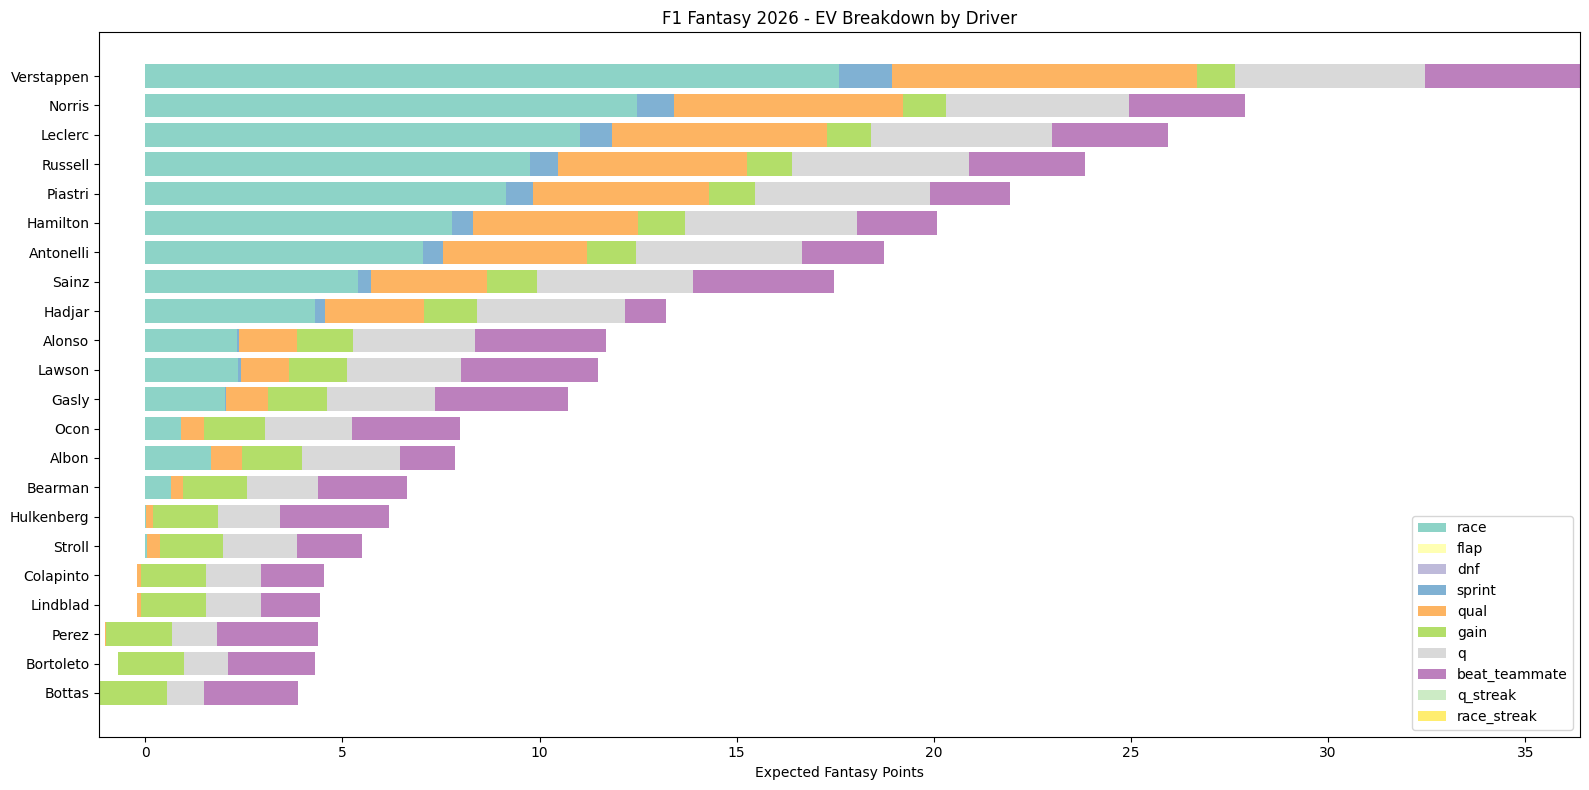

In [41]:
# Stacked bar chart of EV components per driver
fig, ax = plt.subplots(figsize=(16, 8))

ev_components = ['race', 'flap', 'dnf', 'sprint', 'qual', 'gain', 'q', 'beat_teammate', 'q_streak', 'race_streak']
available_components = [c for c in ev_components if c in ev_df.columns]

sorted_drivers = ev_df[available_components].sum(axis=1).sort_values(ascending=True).index

bottom = np.zeros(len(sorted_drivers))
colors = plt.cm.Set3(np.linspace(0, 1, len(available_components)))

for i, component in enumerate(available_components):
    values = ev_df.loc[sorted_drivers, component].values
    ax.barh(range(len(sorted_drivers)), values, left=bottom, label=component, color=colors[i])
    bottom += values

ax.set_yticks(range(len(sorted_drivers)))
ax.set_yticklabels(sorted_drivers)
ax.set_xlabel('Expected Fantasy Points')
ax.set_title('F1 Fantasy 2026 - EV Breakdown by Driver')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Notes on 2026 Regulation Reset

**Key uncertainties for 2026 predictions:**

1. **New regulation era**: The 2026 rules represent a fundamental reset. Historical performance from 2022-2025 is less predictive than usual. The odds markets (which incorporate pre-season testing and expert analysis) are our best signal.

2. **Power unit maturity**: New PU formula means manufacturers start from scratch. Teams with better electrical systems (MGU-K tripled to 350kW) will have structural advantages. Mercedes supplies 4 teams, Ferrari 3, RBPT 2, Honda 1, Audi 1.

3. **Active aero dynamics**: DRS is gone. Overtaking now depends on electrical energy management (Boost/Overtake modes). This could change the typical grid-to-race-position relationship.

4. **New teams**: Cadillac (11th team) and Audi (rebranded Sauber) add significant uncertainty. Both are expected to be at the back initially.

5. **Pre-season testing signals** (Bahrain 2026):
   - Ferrari (Leclerc): Fastest overall - 1:31.992
   - Mercedes (Antonelli): 2nd - 1:32.803
   - McLaren (Piastri/Norris): 3rd/4th - within 0.1s of each other
   - Red Bull (Verstappen): 5th - 1:33.109

**Model accuracy**: As with 2024, formal backtesting is not possible. The model's value lies in systematically converting market odds into optimal Fantasy team selections, not in predicting individual race outcomes.